In [1]:
import os

# This forces TensorFlow to use the internal Keras 2 instead of the new Keras 3
os.environ["TF_USE_LEGACY_KERAS"] = "1"

# Transfer Learning with TensorFlow Part 2: Fine-tuning

In the previous file, we saw how we could leverage feature extraction transfer learning to get far better results on our Food Vision project than building our own models (even with less data).

Now we're going to cover another type of transfer learning: fine-tuning.

In **fine-tuning transfer learning** the pre-trained model weights from another model are unfrozen and tweaked during to better suit your own data.

For feature extraction transfer learning, you may only train the top 1-3 layers of a pre-trained model with your own data, in fine-tuning transfer learning, you might train 1-3+ layers of a pre-trained model (where the '+' indicates that many or all of the layers could be trained).

![](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/05-transfer-learning-feature-extraction-vs-fine-tuning.png)
*Feature extraction transfer learning vs. fine-tuning transfer learning. The main difference between the two is that in fine-tuning, more layers of the pre-trained model get unfrozen and tuned on custom data. This fine-tuning usually takes more data than feature extraction to be effective.*

## What we're going to cover

We're going to go through the follow with TensorFlow:

- Introduce fine-tuning, a type of transfer learning to modify a pre-trained model to be more suited to your data
- Using the Keras Functional API (a differnt way to build models in Keras)
- Using a smaller dataset to experiment faster (e.g. 1-10% of training samples of 10 classes of food)
- Data augmentation (how to make your training dataset more diverse without adding more data)
- Running a series of modelling experiments on our Food Vision data
  - **Model 0**: a transfer learning model using the Keras Functional API
  - **Model 1**: a feature extraction transfer learning model on 1% of the data with data augmentation
  - **Model 2**: a feature extraction transfer learning model on 10% of the data with data augmentation
  - **Model 3**: a fine-tuned transfer learning model on 10% of the data
  - **Model 4**: a fine-tuned transfer learning model on 100% of the data
- Introduce the ModelCheckpoint callback to save intermediate training results
- Compare model experiments results using TensorBoard

## Creating helper functions

Throughout our machine learning experiments, we'll likely come across snippets of code you want to use over and over again.

For example, a plotting function which plots a model's `history` object (see `plot_loss_curves()` below).

You could recreate these functions over and over again.

But as you might've guessed, rewritting the same functions becomes tedious.

One of the solutions is to store them in a helper script such as [`helper_functions.py`](https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/helper_functions.py). And then import the necesary functionality when you need it.

For example, you might write:

```
from helper_functions import plot_loss_curves

...

plot_loss_curves(history)
```

In [3]:
# Importing Helper Functions:

#import wget

#url = 'https://raw.githubusercontent.com/Shailya777/Learning-Logs/refs/heads/main/Deep_Learning_with_Tensorflow/helper_functions.py'

#file = wget.download(url)

from helper_functions import plot_loss_curves, create_tensorboard_callback, walk_through_dir, unzip_data

## 10 Food Classes: Working with less data

We saw in the previous notebook that we could get great results with only 10% of the training data using transfer learning with TensorFlow Hub.

In this notebook, we're going to continue to work with smaller subsets of the data, except this time we'll have a look at how we can use the in-built pretrained models within the [`tf.keras.applications`](https://www.tensorflow.org/api_docs/python/tf/keras/applications) module as well as how to fine-tune them to our own custom dataset.

We'll also practice using a new but similar dataloader function to what we've used before, [`image_dataset_from_directory()`](https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory)

Finally, we'll also be practicing using the [Keras Functional API](https://keras.io/guides/functional_api/) for building deep learning models. The Functional API is a more flexible way to create models than the tf.keras.Sequential API.

In [5]:
# Downloading The Data:

import wget

url = 'https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_10_percent.zip'

file = wget.download(url)

100% [......................................................................] 168546183 / 168546183

In [6]:
# Unzipping The Data Using unzip_data from Helper Functions:

unzip_data(filename= '10_food_classes_10_percent.zip')

In [4]:
# Walking Through Data Directory Using walk_through_dir Helper Function:

walk_through_dir('10_food_classes_10_percent')

There are 2 directories and 0 images in '10_food_classes_10_percent'.
There are 10 directories and 0 images in '10_food_classes_10_percent/train'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/pizza'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/steak'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_wings'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/grilled_salmon'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/hamburger'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/chicken_curry'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ice_cream'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/ramen'.
There are 0 directories and 75 images in '10_food_classes_10_percent/train/sushi'.
There are 0 directories and 75 images in '10_food_classes_10_percent/trai

In [5]:
# Creating Training and Test Data Directory Paths:

train_dir = '10_food_classes_10_percent/train/'
test_dir = '10_food_classes_10_percent/test/'

Now we've got some image data, we need a way of loading it into a TensorFlow compatible format.

Previously, we've used the [`ImageDataGenerator`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image/ImageDataGenerator) class.

However, as of August 2023, this class is deprecated and isn't recommended for future usage (it's too slow).

Because of this, we'll move onto using `tf.keras.utils.image_dataset_from_directory()`.

This method expects image data in the following file format:

```
Example of file structure

10_food_classes_10_percent <- top level folder
└───train <- training images
│   └───pizza
│   │   │   1008104.jpg
│   │   │   1638227.jpg
│   │   │   ...      
│   └───steak
│       │   1000205.jpg
│       │   1647351.jpg
│       │   ...
│   
└───test <- testing images
│   └───pizza
│   │   │   1001116.jpg
│   │   │   1507019.jpg
│   │   │   ...      
│   └───steak
│       │   100274.jpg
│       │   1653815.jpg
│       │   ...    
```

One of the main benefits of using [`tf.keras.prepreprocessing.image_dataset_from_directory()`](https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/image_dataset_from_directory) rather than `ImageDataGenerator` is that it creates a [`tf.data.Dataset`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset) object rather than a generator.

The main advantage of this is the `tf.data.Dataset` API is much more efficient (faster) than the `ImageDataGenerator` API which is paramount for larger datasets.

In [7]:
# Creating Training and Testing Data Inputs:

import tensorflow as tf


IMG_SHAPE = (224, 224) # Target Image Size to feed into Models

train_data_10_percent = tf.keras.preprocessing.image_dataset_from_directory(directory= train_dir,
                                                                           image_size= IMG_SHAPE,
                                                                           label_mode= 'categorical',
                                                                           batch_size= 32)

test_data = tf.keras.preprocessing.image_dataset_from_directory(directory= test_dir,
                                                               image_size= IMG_SHAPE,
                                                               label_mode= 'categorical',
                                                               batch_size= 32)

Found 750 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


Looks like our dataloaders have found the correct number of images for each dataset.

For now, the main parameters we're concerned about in the `image_dataset_from_directory()` funtion are:
* `directory` - the filepath of the target directory we're loading images in from.
* `image_size` - the target size of the images we're going to load in (height, width).
* `batch_size` - the batch size of the images we're going to load in. For example if the `batch_size` is 32 (the default), batches of 32 images and labels at a time will be passed to the model.

There are more we could play around with if we needed to [in the [documentation](https://www.tensorflow.org/api_docs/python/tf/keras/utils/image_dataset_from_directory).

In [8]:
# Checking Training Data:

train_data_10_percent

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 10), dtype=tf.float32, name=None))>

In the above output:

* `(None, 224, 224, 3)` refers to the tensor shape of our images where `None` is the batch size, `224` is the height (and width) and `3` is the color channels (red, green, blue).
* `(None, 10)` refers to the tensor shape of the labels where `None` is the batch size and `10` is the number of possible labels (the 10 different food classes).
* Both image tensors and labels are of the datatype `tf.float32`.

The `batch_size` is `None` due to it only being used during model training. You can think of `None` as a placeholder waiting to be filled with the `batch_size` parameter from `image_dataset_from_directory()`.

Another benefit of using the `tf.data.Dataset` API are the assosciated methods which come with it.

For example, if we want to find the name of the classes we were working with, we could use the `class_names` attribute

In [9]:
# Checking out Class Names of Dataset:

train_data_10_percent.class_names

['chicken_curry',
 'chicken_wings',
 'fried_rice',
 'grilled_salmon',
 'hamburger',
 'ice_cream',
 'pizza',
 'ramen',
 'steak',
 'sushi']

In [10]:
# Seeing Example of Training Data:

for images, labels in train_data_10_percent.take(1):
    print(images, labels)

tf.Tensor(
[[[[1.82795914e+02 1.69795914e+02 1.27795921e+02]
   [1.94045929e+02 1.80045929e+02 1.41045929e+02]
   [2.07234695e+02 1.93448975e+02 1.59091843e+02]
   ...
   [9.82551270e+01 7.27552795e+01 2.56123352e+01]
   [1.16433723e+02 1.05148094e+02 5.13623505e+01]
   [1.24836845e+02 1.23423668e+02 6.67807770e+01]]

  [[1.75056122e+02 1.62056122e+02 1.20056122e+02]
   [1.65964279e+02 1.51964279e+02 1.12964279e+02]
   [1.99913269e+02 1.85698975e+02 1.51556122e+02]
   ...
   [9.03112488e+01 6.66685486e+01 1.91939068e+01]
   [9.34285736e+01 8.49950027e+01 2.57857513e+01]
   [9.89337845e+01 1.02510391e+02 3.58165054e+01]]

  [[1.47964279e+02 1.32964279e+02 8.99642868e+01]
   [1.71061234e+02 1.56903061e+02 1.17704086e+02]
   [1.94260208e+02 1.80045914e+02 1.45903061e+02]
   ...
   [1.13852394e+02 9.03525467e+01 4.32809258e+01]
   [1.15331551e+02 1.07642868e+02 4.36988983e+01]
   [1.08198959e+02 1.11984772e+02 3.49795952e+01]]

  ...

  [[2.31780594e+02 2.20209122e+02 2.08209122e+02]
   [2

2026-01-19 12:24:41.879487: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Notice how the image arrays come out as tensors of pixel values where as the labels come out as one-hot encodings (e.g. `[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]` for `hamburger`).

### Model 0: Building a transfer learning model using the Keras Functional API

Alright, our data is tensor-ified, let's build a model.

To do so we're going to be using the [`tf.keras.applications`](https://www.tensorflow.org/api_docs/python/tf/keras/applications) module as it contains a series of already trained (on ImageNet) computer vision models as well as the Keras Functional API to construct our model.

We're going to go through the following steps:

1. Instantiate a pre-trained base model object by choosing a target model such as [`EfficientNetV2B0`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/efficientnet_v2/EfficientNetV2B0) from [`tf.keras.applications.efficientnet_v2`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/efficientnet_v2), setting the `include_top` parameter to `False` (we do this because we're going to create our own top, which are the output layers for the model).
2. Set the base model's `trainable` attribute to `False` to freeze all of the weights in the pre-trained model.
3. Define an input layer for our model, for example, what shape of data should our model expect?
4. [Optional] Normalize the inputs to our model if it requires. Some computer vision models such as `ResNetV250` require their inputs to be between 0 & 1.

As of writing, the `EfficientNet` (and `EfficientNetV2`) models in the `tf.keras.applications` module do not require images to be normalized (pixel values between 0 and 1) on input, where as many of the other models do.

5. Pass the inputs to the base model.
6. Pool the outputs of the base model into a shape compatible with the output activation layer (turn base model output tensors into same shape as label tensors). This can be done using [`tf.keras.layers.GlobalAveragePooling2D()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling2D) or [`tf.keras.layers.GlobalMaxPooling2D()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalMaxPool2D?hl=en) though the former is more common in practice.
7. Create an output activation layer using `tf.keras.layers.Dense()` with the appropriate activation function and number of neurons.
8. Combine the inputs and outputs layer into a model using [`tf.keras.Model()`](https://www.tensorflow.org/api_docs/python/tf/keras/Model).
9. Compile the model using the appropriate loss function and choose of optimizer.
10. Fit the model for desired number of epochs and with necessary callbacks (in our case, we'll start off with the TensorBoard callback).

### Model 0 : Building a Transfer Learning Feature Extraction Model Using Keras Functional API:

In [11]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.models import Sequential

import warnings
warnings.filterwarnings('ignore')

In [12]:
# Creating BAse Model with tf.keras.applications:
base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top= False)

# Freeze Layers in The Base Model (Underlying Pre-Trained Weights aren't Changed During Training):
base_model.trainable = False

# Create Inputs into The Base Model:
inputs = Input(shape= (224,224,3), name= 'Input_Layer')

# If using ResNet50V2, add this to speed up convergence, remove for EfficientNetV2:
# x = tf.keras.layers.Rescaling(1./255)(inputs)

# Pass The Inputs to The Base Model:
x = base_model(inputs)
print(f'Shape after Passing Input Through Base Model: {x.shape}')

# Average Pool the Output of The Base Model (Aggregate all the most Important Information, reduce number of computations):
x = GlobalAveragePooling2D(name= 'Global_Average_Pooling_Layer')(x)
print(f'Shape After Global Average Pooling: {x.shape}')

# Create The Output Activation Layer:
outputs = Dense(units= 10, activation= 'softmax', name= 'Output_Layer')(x)

# Combine Inputs with The Outputs into The Model:
model_0 = Model(inputs, outputs)

# Compile The Model:
model_0.compile(optimizer= Adam(),
               loss= CategoricalCrossentropy(),
               metrics= ['accuracy'])

# Fitting The Model:
history_0_10_percent = model_0.fit(train_data_10_percent,
                                  epochs= 5,
                                  validation_data= test_data,
                                  callbacks= [create_tensorboard_callback('Transfer Learning', '10_percent_feature_extract')])

Shape after Passing Input Through Base Model: (None, 7, 7, 1280)
Shape After Global Average Pooling: (None, 1280)
Saving TensorBoard log files to: Transfer Learning/10_percent_feature_extract/20260119-122532
Epoch 1/5


2026-01-19 12:25:37.961025: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-01-19 12:25:40.155241: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f1c88e413e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-19 12:25:40.155279: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-01-19 12:25:40.180216: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1768825540.916738     891 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


24/24 [==============================] - 14s 218ms/step - loss: 1.8781 - accuracy: 0.4107 - val_loss: 1.3245 - val_accuracy: 0.7164
Epoch 2/5
24/24 [==============================] - 3s 131ms/step - loss: 1.1443 - accuracy: 0.7293 - val_loss: 0.9023 - val_accuracy: 0.8012
Epoch 3/5
24/24 [==============================] - 3s 130ms/step - loss: 0.8438 - accuracy: 0.8187 - val_loss: 0.7257 - val_accuracy: 0.8324
Epoch 4/5
24/24 [==============================] - 3s 130ms/step - loss: 0.6903 - accuracy: 0.8493 - val_loss: 0.6330 - val_accuracy: 0.8468
Epoch 5/5
24/24 [==============================] - 3s 133ms/step - loss: 0.6016 - accuracy: 0.8507 - val_loss: 0.5740 - val_accuracy: 0.8532


This is incredible.

All thanks to the power of transfer learning!

It's important to note the kind of transfer learning we used here is called feature extraction transfer learning, similar to what we did with the TensorFlow Hub models.

In other words, we passed our custom data to an already pre-trained model (`EfficientNetV2B0`), asked it "what patterns do you see?" and then put our own output layer on top to make sure the outputs were tailored to our desired number of classes.

We also used the Keras Functional API to build our model rather than the Sequential API. For now, the benefits of this main not seem clear but when you start to build more sophisticated models, you'll probably want to use the Functional API. So it's important to have exposure to this way of building models.

To see the benefits and use cases of the Functional API versus the Sequential API, check out the [TensorFlow Functional API documentation](https://www.tensorflow.org/guide/keras/functional).

In [13]:
# Checking out Layers of Base Model:
base_model.layers

In [14]:
type(base_model.layers)

list

In [15]:
for layer_number, layer in enumerate(base_model.layers):
    print(layer_number, layer.name)

0 input_1
1 rescaling
2 normalization
3 stem_conv
4 stem_bn
5 stem_activation
6 block1a_project_conv
7 block1a_project_bn
8 block1a_project_activation
9 block2a_expand_conv
10 block2a_expand_bn
11 block2a_expand_activation
12 block2a_project_conv
13 block2a_project_bn
14 block2b_expand_conv
15 block2b_expand_bn
16 block2b_expand_activation
17 block2b_project_conv
18 block2b_project_bn
19 block2b_drop
20 block2b_add
21 block3a_expand_conv
22 block3a_expand_bn
23 block3a_expand_activation
24 block3a_project_conv
25 block3a_project_bn
26 block3b_expand_conv
27 block3b_expand_bn
28 block3b_expand_activation
29 block3b_project_conv
30 block3b_project_bn
31 block3b_drop
32 block3b_add
33 block4a_expand_conv
34 block4a_expand_bn
35 block4a_expand_activation
36 block4a_dwconv2
37 block4a_bn
38 block4a_activation
39 block4a_se_squeeze
40 block4a_se_reshape
41 block4a_se_reduce
42 block4a_se_expand
43 block4a_se_excite
44 block4a_project_conv
45 block4a_project_bn
46 block4b_expand_conv
47 block

In [16]:
# Model Summary:
base_model.summary()

Model: "efficientnetv2-b0"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, None, None, 3)]      0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, None, None, 3)        0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, None, None, 3)        0         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 stem_conv (Conv2D)          (None, None, None, 32)       864       ['normalizatio

You can see how each of the different layers have a certain number of parameters each. Since we are using a pre-trained model, you can think of all of these parameters are patterns the base model has learned on another dataset. And because we set `base_model.trainable = False`, these patterns remain as they are during training (they're frozen and don't get updated).

In [17]:
# Summary of The Whole Model:
model_0.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_Layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetv2-b0 (Functio  (None, None, None, 1280   5919312   
 nal)                        )                                   
                                                                 
 Global_Average_Pooling_Lay  (None, 1280)              0         
 er (GlobalAveragePooling2D                                      
 )                                                               
                                                                 
 Output_Layer (Dense)        (None, 10)                12810     
                                                                 
Total params: 5932122 (22.63 MB)
Trainable params: 12810 (50.04 KB)
Non-trainable params: 5919312 (22.58 MB)
__________________

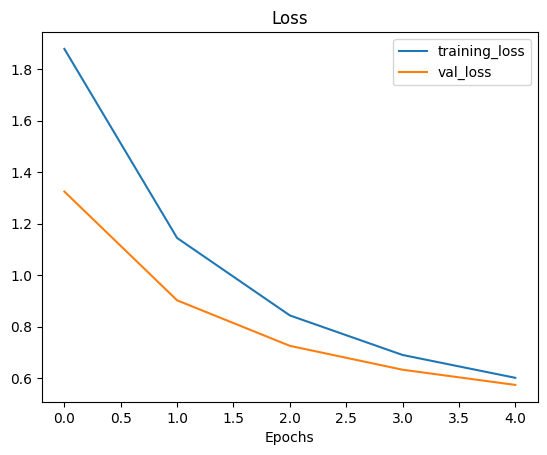

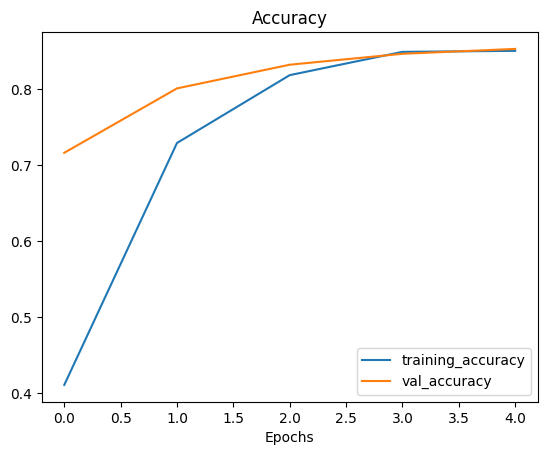

In [18]:
# Loass and Accuracy Curves:
plot_loss_curves(history= history_0_10_percent)

## Getting a feature vector from a trained model

Question:** What happens with the `tf.keras.layers.GlobalAveragePooling2D()` layer?

The [`tf.keras.layers.GlobalAveragePooling2D()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling2D) layer transforms a 4D tensor into a 2D tensor by averaging the values across the inner-axes.

In [19]:
# Defining a Input Tensor Shape (Same Number of Dimensions as The Output of efficientnet_v2.EfficientNetV2B0):
input_shape = (1, 4, 4, 3)

# Creating a Random Tensor:
tf.random.set_seed(42)
input_tensor = tf.random.normal(shape= input_shape)
print(f'Random Input Tensor:\n {input_tensor}\n')

# Pass the Random Tensor Through Global Average Pooling 2D Layer:
global_average_pooled_tensor = GlobalAveragePooling2D()(input_tensor)
print(f'Global Average Pooled Random Tensor:\n {global_average_pooled_tensor}\n')

# Shapes of Both Tensors:
print(f'Shape of Random Input Tensor: {input_tensor.shape}')
print(f'Shape of Average Global Pooled Layer: {global_average_pooled_tensor.shape}')

Random Input Tensor:
 [[[[ 0.3274685  -0.8426258   0.3194337 ]
   [-1.4075519  -2.3880599  -1.0392479 ]
   [-0.5573232   0.539707    1.6994323 ]
   [ 0.28893656 -1.5066116  -0.2645474 ]]

  [[-0.59722406 -1.9171132  -0.62044144]
   [ 0.8504023  -0.40604794 -3.0258412 ]
   [ 0.9058464   0.29855987 -0.22561555]
   [-0.7616443  -1.8917141  -0.93847126]]

  [[ 0.77852213 -0.47338894  0.97772694]
   [ 0.24694404  0.20573746 -0.52562326]
   [ 0.32410017  0.02545409 -0.10638496]
   [-0.63694745  1.1603122   0.2507359 ]]

  [[-0.41728503  0.4012578  -1.4145443 ]
   [-0.5931857  -1.6617213   0.33567193]
   [ 0.10815628  0.23479679 -0.56668764]
   [-0.35819843  0.88698614  0.52744764]]]]

Global Average Pooled Random Tensor:
 [[-0.09368646 -0.45840448 -0.2885598 ]]

Shape of Random Input Tensor: (1, 4, 4, 3)
Shape of Average Global Pooled Layer: (1, 3)


You can see the `tf.keras.layers.GlobalAveragePooling2D()` layer condensed the input tensor from shape `(1, 4, 4, 3)` to `(1, 3)`. It did so by averaging the `input_tensor` across the middle two axes.

We can replicate this operation using the `tf.reduce_mean()` operation and specifying the appropriate axes.

In [20]:
# Replicating Same Operation as GlobaGlobalAveragePooling2D():
tf.reduce_mean(input_tensor, axis= [1,2])

<tf.Tensor: shape=(1, 3), dtype=float32, numpy=array([[-0.09368646, -0.45840448, -0.2885598 ]], dtype=float32)>

Doing this not only makes the output of the base model compatible with the input shape requirement of our output layer (`tf.keras.layers.Dense()`), it also condenses the information found by the base model into a lower dimension **feature vector**.

One of the reasons feature extraction transfer learning is named how it is is because what often happens is a pretrained model outputs a **feature vector** (a long tensor of numbers, in our case, this is the output of the [`tf.keras.layers.GlobalAveragePooling2D()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling2D) layer) which can then be used to extract patterns out of.

## Running a series of transfer learning experiments

We've seen the incredible results of transfer learning on 10% of the training data, what about 1% of the training data?

What kind of results do you think we can get using 100x less data than the original CNN models we built ourselves?

Why don't we answer that question while running the following modelling experiments:
1. **Model 1**: Use feature extraction transfer learning on 1% of the training data with data augmentation.
2. **Model 2**: Use feature extraction transfer learning on 10% of the training data with data augmentation and save the results to a checkpoint.
3. **Model 3**: Fine-tune the **Model 2** checkpoint on 10% of the training data with data augmentation.
4. **Model 4**: Fine-tune the **Model 2** checkpoint on 100% of the training data with data augmentation.

While all of the experiments will be run on different versions of the training data, they will all be evaluated on the **same test dataset**, this ensures the results of each experiment are as comparable as possible.

All experiments will be done using the `EfficientNetV2B0` model within the `tf.keras.applications.efficientnet_v2` module.

To make sure we're keeping track of our experiments, we'll use our `create_tensorboard_callback()` function to log all of the model training logs.

We'll construct each model using the Keras Functional API and instead of implementing data augmentation in the `ImageDataGenerator` class as we have previously, we're going to build it right into the model using the [`tf.keras.layers`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/) module.

Let's begin by downloading the data for experiment 1, using feature extraction transfer learning on 1% of the training data with data augmentation.

In [22]:
# Downloading The Data:

url = 'https://storage.googleapis.com/ztm_tf_course/food_vision/10_food_classes_1_percent.zip'
file = wget.download(url)

100% [......................................................................] 133612354 / 133612354

In [23]:
# Unzipping The Data:
unzip_data('10_food_classes_1_percent.zip')

In [26]:
# Creating Training and Test Directory Paths:
train_dir_1_percent = '10_food_classes_1_percent/train/'
test_dir = '10_food_classes_1_percent/test/'

In [25]:
# Walking Through 1 Percent Directory:
walk_through_dir('10_food_classes_1_percent')

There are 2 directories and 0 images in '10_food_classes_1_percent'.
There are 10 directories and 0 images in '10_food_classes_1_percent/train'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/pizza'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/steak'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_wings'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/grilled_salmon'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/hamburger'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/chicken_curry'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ice_cream'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/ramen'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/sushi'.
There are 0 directories and 7 images in '10_food_classes_1_percent/train/fried_rice'.
There a

In [27]:
# Creating Training and Testing Data Loaders (Inputs):

IMG_SHAPE = (224,224)

train_data_1_percent = tf.keras.preprocessing.image_dataset_from_directory(directory= train_dir_1_percent,
                                                                          image_size= IMG_SHAPE,
                                                                          label_mode= 'categorical',
                                                                          batch_size= 32)

test_data = tf.keras.preprocessing.image_dataset_from_directory(directory= test_dir,
                                                               image_size= IMG_SHAPE,
                                                               label_mode= 'categorical',
                                                               batch_size= 32)

Found 70 files belonging to 10 classes.
Found 2500 files belonging to 10 classes.


### Adding data augmentation right into the model

Previously we've used the different parameters of the `ImageDataGenerator` class to augment our training images, this time we're going to build data augmentation right into the model.

Using the [`tf.keras.layers`](https://www.tensorflow.org/api_docs/python/tf/keras/layers) module and creating a dedicated data augmentation layer.

This a relatively new feature added to TensorFlow 2.10+ but it's very powerful. Adding a data augmentation layer to the model has the following benefits:
* Preprocessing of the images (augmenting them) happens on the GPU rather than on the CPU (much faster).
  * Images are best preprocessed on the GPU where as text and structured data are more suited to be preprocessed on the CPU.
* Image data augmentation only happens during training so we can still export our whole model and use it elsewhere. And if someone else wanted to train the same model as us, including the same kind of data augmentation, they could.

![](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/05-data-augmentation-inside-a-model.png)
*Example of using data augmentation as the first layer within a model (EfficientNetB0).*

> 📚 **Resource:** For more information on different methods of data augmentation, check out the the [TensorFlow data augmentation guide](https://www.tensorflow.org/tutorials/images/data_augmentation).

To use data augmentation right within our model we'll create a Keras Sequential model consisting of only data preprocessing layers, we can then use this Sequential model within another Functional model.

If that sounds confusing, it'll make sense once we create it in code.

The data augmentation transformations we're going to use are:
* [`tf.keras.layers.RandomFlip`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomFlip) - flips image on horizontal or vertical axis.
* [`tf.keras.layers.RandomRotation`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomRotation) - randomly rotates image by a specified amount.
* [`tf.keras.layers.RandomZoom`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomZoom) - randomly zooms into an image by specified amount.
* [`tf.keras.layers.RandomHeight`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomHeight) - randomly shifts image height by a specified amount.
* [`tf.keras.layers.RandomWidth`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/RandomWidth) - randomly shifts image width by a specified amount.
* [`tf.keras.layers.Rescaling`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Rescaling) - normalizes the image pixel values to be between 0 and 1, this is worth mentioning because it is required for some image models but since we're using [`tf.keras.applications.efficientnet_v2.EfficientNetV2B0`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/efficientnet_v2/EfficientNetV2B0), it's not required (the model pretrained model implements rescaling itself).


In [28]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomHeight, RandomWidth, Rescaling

In [29]:
# Creating a Sequential Model to add All Image Augmentation Layers together:

data_augmentation = Sequential(name= 'Data_Augmentation')
data_augmentation.add(RandomFlip(mode= 'horizontal'))
data_augmentation.add(RandomRotation(factor= 0.2))
data_augmentation.add(RandomZoom(height_factor= 0.2))
data_augmentation.add(RandomHeight(factor= 0.2))
data_augmentation.add(RandomWidth(factor= 0.2))
# data_augmentation.add(Rescaling(scale= 1/255)) # keep for ResNet50V2, remove for EfficientNetV2B0

Our data augmentation Sequential model is ready to go. As you'll see shortly, we'll be able to slot this "model" as a layer into our transfer learning model later on.

But before we do that, let's test it out by passing random images through it.

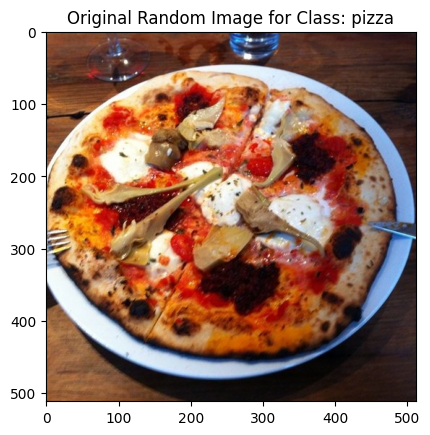

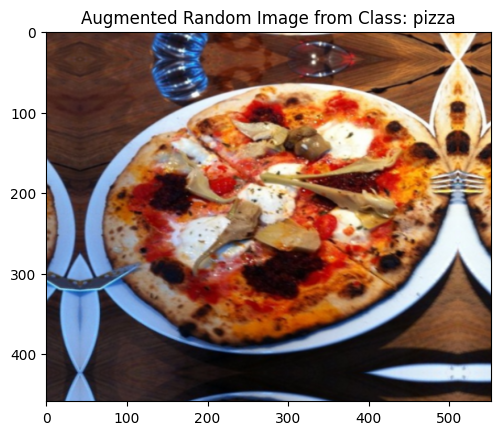

In [32]:
# View a Random Image after Applying Data Augmentation on it:

import matplotlib.pyplot as plt
import os
import random

target_class = random.choice(train_data_1_percent.class_names) # Chose a Random Class
target_dir = '10_food_classes_1_percent/train/' + target_class
random_image = random.choice(os.listdir(target_dir))
random_image_path = target_dir + '/' + random_image
image = plt.imread(random_image_path)
plt.imshow(image)
plt.title(f'Original Random Image for Class: {target_class}')
plt.show()

# Augmenting The Image:
augmented_image = data_augmentation(tf.expand_dims(image, axis= 0)) # data augmentation model requires shape (None, height, width, 3)
plt.imshow(tf.squeeze(augmented_image) / 255) # requires normalization after augmentation
plt.title(f'Augmented Random Image from Class: {target_class}')
plt.show()

Run the cell above a few times and you can see the different random augmentations on different classes of images. Because we're going to add the data augmentation model as a layer in our upcoming transfer learning model, it'll apply these kind of random augmentations to each of the training images which passes through it.

Doing this will make our training dataset a little more varied. You can think of it as if you were taking a photo of food in real-life, not all of the images are going to be perfect, some of them are going to be orientated in strange ways. These are the kind of images we want our model to be able to handle.

Speaking of model, let's build one with the Functional API. We'll run through all of the same steps as before except for one difference, we'll add our data augmentation Sequential model as a layer immediately after the input layer.

## Model 1: Feature extraction transfer learning on 1% of the data with data augmentation

In [34]:
# Setting Up Input Shape and Base Model, freezing The Base Model Layers:
input_shape = (224, 224, 3)
base_model= tf.keras.applications.efficientnet_v2.EfficientNetV2B0(include_top= False)
base_model.trainable= False

# Creating Input Layer:
inputs = Input(shape= input_shape, name= 'Input_Layer')

# Add in Data Augmentation Sequential Model as a Layer in the Model:
x = data_augmentation(inputs)

# Give vase_model inputs after Augmentation and Don't Train it:
x = base_model(x)

# Pool Output Features of Base Model:
x = GlobalAveragePooling2D(name= 'Global_Average_Pooling_Layer')(x)

# Putting a Dense Layer on as The Output:
outputs = Dense(units= 10, activation= 'Softmax',
               name= 'Output_Layer')(x)

# Making a Model with Inputs and Outputs:
model_1 = Model(inputs, outputs)

# Compiling The Model:
model_1.compile(optimizer= Adam(),
               loss= CategoricalCrossentropy(),
               metrics= ['accuracy'])

# Fitting The Model:
history_1_percent = model_1.fit(train_data_1_percent,
                               validation_data= test_data,
                               epochs= 5,
                               callbacks= [create_tensorboard_callback(dir_name= 'Transfer Learning',
                                                                      experiment_name= '1_percent_data_aug')])

Saving TensorBoard log files to: Transfer Learning/1_percent_data_aug/20260119-131121
Epoch 1/5
3/3 [==============================] - 10s 2s/step - loss: 2.4670 - accuracy: 0.1143 - val_loss: 2.2406 - val_accuracy: 0.2112
Epoch 2/5
3/3 [==============================] - 4s 2s/step - loss: 2.2345 - accuracy: 0.2143 - val_loss: 2.1289 - val_accuracy: 0.2944
Epoch 3/5
3/3 [==============================] - 3s 1s/step - loss: 2.0971 - accuracy: 0.3429 - val_loss: 2.0248 - val_accuracy: 0.3636
Epoch 4/5
3/3 [==============================] - 3s 1s/step - loss: 1.9700 - accuracy: 0.3714 - val_loss: 1.9293 - val_accuracy: 0.4120
Epoch 5/5
3/3 [==============================] - 3s 1s/step - loss: 1.8379 - accuracy: 0.5000 - val_loss: 1.8460 - val_accuracy: 0.4552


Using only 7 training images per class, using transfer learning our model was able to get ~45%+ accuracy on the validation set.

This result is pretty amazing since the [original Food-101 paper](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf) achieved 50.67% accuracy with all the data, namely, 750 training images per class (**note:** this metric was across 101 classes, not 10, we'll get to 101 classes soon).

If we check out a summary of our model, we should see the data augmentation layer just after the input layer.

In [35]:
# Summary of The Model:
model_1.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 Input_Layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 Data_Augmentation (Sequent  (None, None, None, 3)     0         
 ial)                                                            
                                                                 
 efficientnetv2-b0 (Functio  (None, None, None, 1280   5919312   
 nal)                        )                                   
                                                                 
 Global_Average_Pooling_Lay  (None, 1280)              0         
 er (GlobalAveragePooling2D                                      
 )                                                               
                                                                 
 Output_Layer (Dense)        (None, 10)                1281

We've now got data augmentation built right into the our model. This means if we saved it and reloaded it somewhere else, the data augmentation layers would come with it.

The important thing to remember is **data augmentation only runs during training**. So if we were to evaluate or use our model for inference (predicting the class of an image) the data augmentation layers will be automatically turned off.

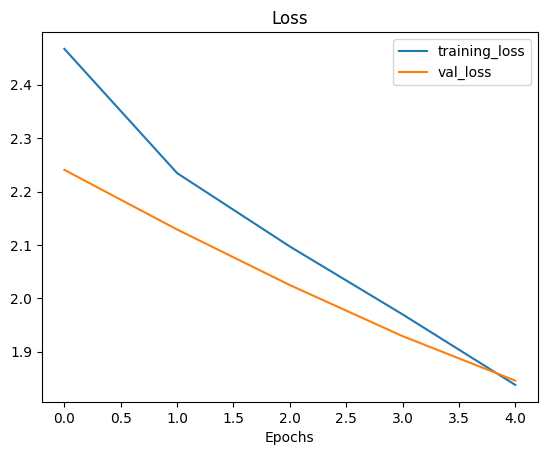

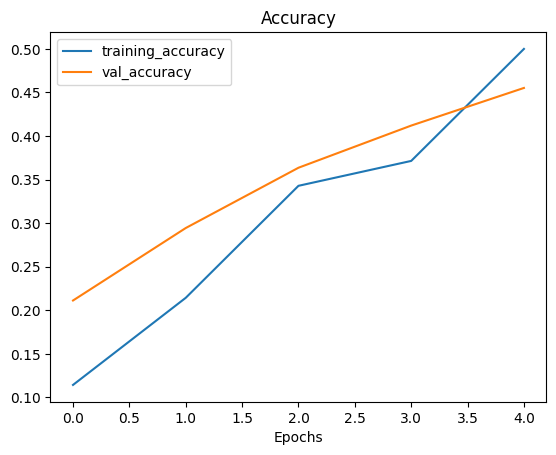

In [36]:
# Plotting Loss Curves of The Model:
plot_loss_curves(history_1_percent)

It looks like the metrics on both datasets would improve if we kept training for more epochs.